# Quantized CNN Training for Posture Classification (HGQ2-based QAT)

**Architecture**
- 3 QConv2D layers with QBatchNormalization
- Filter progression: [16, 16, 24]
- GlobalAveragePooling2D for efficiency
- Output: QDense(NUM_CLASSES) (logits output, no softmax)

**Quantization Strategy (HGQ2)**
- Fixed 8-bit quantization (`k0=0`) for both weights and activations
- `kbi` quantizer for weights (SAT_SYM overflow)
- `kif` quantizer for activations (WRAP overflow)
- Effective Bit-Operations (EBOPs) tracking for resource estimation

This notebook follows the HGQ2 best-practice patterns demonstrated in:
- [1] `small_jet_tagger.ipynb`
- [2] `larger_jet_tagger.ipynb`

**Hyperparameters**
- Learning rate: 0.001
- Batch size: 32
- Kernel size: (3, 3)
- L1 regularization: 1e-4
- Early stopping patience: 15
- Max epochs: 50

## Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Keras 3
import keras

# TensorFlow
import tensorflow as tf

# Package imports
from bedposip.data import load_dataset, preprocess_data
from bedposip.model import (
    create_quantized_model,
    get_callbacks,
    train_model,
)
from bedposip.utils import (
    check_layer_trainable_params,
    plot_training_history,
    class_report_metric,
    save_model,
    inspect_quantization_bits, 
    plot_quantization_bits
)

# HGQ2 quantization-aware training
from hgq.config import QuantizerConfigScope, LayerConfigScope
from hgq.utils import trace_minmax
from hgq.regularizers import MonoL1

# Configure matplotlib for PDF export with serif font
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern Serif",
})

# Ensure figures directory exists
os.makedirs('figures', exist_ok=True)

I0000 00:00:1780590327.360353    4352 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Set random seed for reproducibility
np.random.seed(42)
keras.utils.set_random_seed(42)

# Constant number of postures
NUM_CLASSES = 3

# Constant for training quantizers bit-width optimizations
REGULARIZER = 1e-5

# Check GPU
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data

### Loading

In [3]:
# Load datasets using package function
X_train, y_train, X_val, y_val, X_test, y_test = load_dataset(type="raw")


Dataset shapes:
  Train: (119999, 64), labels: (119999,)
  Val:   (60000, 64), labels: (60000,)
  Test:  (120001, 64), labels: (120001,)


### Preprocessing

In [4]:
# Preprocess data using package function
(X_train, y_train, X_val, y_val, X_test, y_test, class_names) = preprocess_data(
    X_train, y_train, X_val, y_val, X_test, y_test,
    num_classes=NUM_CLASSES,
)

Label encoding:
  lateral_L -> 0
  lateral_R -> 1
  supine -> 2

One-hot encoded shape: 3

Reshaped data:
  Train: (119999, 8, 8, 1)
  Val:   (60000, 8, 8, 1)
  Test:  (120001, 8, 8, 1)

Data range: [0.0000, 233.4754]
Data dtype: float32


## Configuration

In [ ]:
# Define callbacks using package function
# BetaPID dynamically adjusts beta to steer the model toward a target EBOPs budget.
callbacks = get_callbacks(
    model_name='qat',
    patience=30,
    track_ebops=True,
    target_ebops=800_000,
    init_beta=1e-7,
)

Callbacks configured:
  - EarlyStopping
  - ReduceLROnPlateau
  - FreeEBOPs
  - BetaPID


## Quantized Model

HGQ2 Quantization Configuration

- **`kbi` quantizer** for weights: Fixed 8-bit (4 integer + 4 fractional) with symmetric saturation overflow
- **`kif` quantizer** for activations (datalane): Fixed 8-bit (4 integer + 4 fractional) with wrap-around overflow
- **No softmax in the model**: The output layer produces raw logits

> "QSoftmax is bit-accurate, but it can give exactly zero now: xentropy will diverge and thus USE WITH CAUTION. For classification, it is recommended to NOT to use softmax in the model, but to use it in the loss function"

This approach follows the best practices demonstrated in [1] `small_jet_tagger.ipynb` and [2] `larger_jet_tagger.ipynb`.

In [6]:
from hgq.constraints import MinMax, Max
from hgq.regularizers import MonoL1

with (
    QuantizerConfigScope(place='all', default_q_type='kbi', overflow_mode='SAT_SYM'),
    QuantizerConfigScope(
        place='weight',
        bc=Max(6),
        ic=Max(4),
        i0=2, b0=6,
        br=MonoL1(REGULARIZER),
        ir=MonoL1(REGULARIZER),
        default_q_type='kbi', overflow_mode='SAT_SYM'
    ),
    QuantizerConfigScope(
        place='bias',
        bc=Max(3),
        ic=Max(3),
        i0=2, b0=4,
        br=MonoL1(REGULARIZER),
        ir=MonoL1(REGULARIZER),
        default_q_type='kbi', overflow_mode='SAT_SYM'
    ),
    QuantizerConfigScope(
        place='datalane',
        fc=Max(3),
        ic=Max(6),
        i0=3, f0=3,
        ir=MonoL1(REGULARIZER),
        fr=MonoL1(REGULARIZER),
        default_q_type='kif', overflow_mode='WRAP'
    ),
    LayerConfigScope(enable_ebops=True),  # beta managed by BetaPID callback
):
    model_qat = create_quantized_model(num_classes=NUM_CLASSES)
    model_qat.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.CategoricalCrossentropy(from_logits=True),
        metrics=['accuracy'],
    )

model_qat.summary()
check_layer_trainable_params(model_qat)

I0000 00:00:1780590331.185169    4352 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5121 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:10:00.0, compute capability: 8.6


Model: "posture_classifier_qat"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pressure_map (InputLayer)       │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_1 (QConv2D)               │ (None, 6, 6, 16)       │           771 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_1 (QBatchNormalization) │ (None, 6, 6, 16)       │         1,891 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_1 (Activation)         │ (None, 6, 6, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_2 (QConv2D)               │ (None, 4, 4, 16)       │        10,947 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_2 (QBatchNormalization) │ (None, 4, 4, 16)       │           931 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_2 (Activation)         │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_3 (QConv2D)               │ (None, 2, 2, 24)       │        14,595 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_3 (QBatchNormalization) │ (None, 2, 2, 24)       │           531 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_3 (Activation)         │ (None, 2, 2, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qdense_1 (QDense)               │ (None, 42)             │        16,587 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_1                      │ (None, 42)             │           549 │
│ (QBatchNormalization)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qdense_2 (QDense)               │ (None, 64)             │        11,137 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_2                      │ (None, 64)             │           835 │
│ (QBatchNormalization)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (QDense)                 │ (None, 3)              │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,749 (188.33 KB)

 Trainable params: 41,879 (163.59 KB)

 Non-trainable params: 17,870 (24.74 KB)

### Training

Epoch 1/300


I0000 00:00:1780590340.778914    5044 service.cc:153] XLA service 0x7fbbc0062b60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780590340.778929    5044 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3070, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1780590341.123056    5044 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780590342.576885    5044 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1780590342.666923    5044 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_24205__.129
I0000 00:00:1780590344.935337    5044 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I

 1/59 ━━━━━━━━━━━━━━━━━━━━ 29:33 31s/step - accuracy: 0.3589 - loss: 2.6409

I0000 00:00:1780590363.167493    5044 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5063 - loss: 2.3842

I0000 00:00:1780590365.175549    5041 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_24205__.129
I0000 00:00:1780590365.353744    5041 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1780590366.499413    5041 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1780590367.135269    5041 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1780590367.6284

59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.5078 - loss: 2.3817

I0000 00:00:1780590391.569028    5041 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1780590392.571370    5041 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


59/59 ━━━━━━━━━━━━━━━━━━━━ 64s 579ms/step - accuracy: 0.5929 - loss: 2.2360 - val_accuracy: 0.4270 - val_loss: 2.9648 - learning_rate: 0.0010 - ebops: 2453829.0000 - beta: 1.0000e-07
Epoch 2/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7543 - loss: 1.9370 - val_accuracy: 0.4424 - val_loss: 2.5620 - learning_rate: 0.0010 - ebops: 2443305.0000 - beta: 1.0000e-07
Epoch 3/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7945 - loss: 1.8501 - val_accuracy: 0.5594 - val_loss: 2.1594 - learning_rate: 0.0010 - ebops: 2443196.0000 - beta: 1.0000e-07
Epoch 4/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8110 - loss: 1.8044 - val_accuracy: 0.6424 - val_loss: 2.0277 - learning_rate: 0.0010 - ebops: 2439777.0000 - beta: 1.0000e-07
Epoch 5/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8235 - loss: 1.7712 - val_accuracy: 0.7793 - val_loss: 1.6403 - learning_rate: 0.0010 - ebops: 2450355.0000 - beta: 1.0000e-07
Epoch 6/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/st

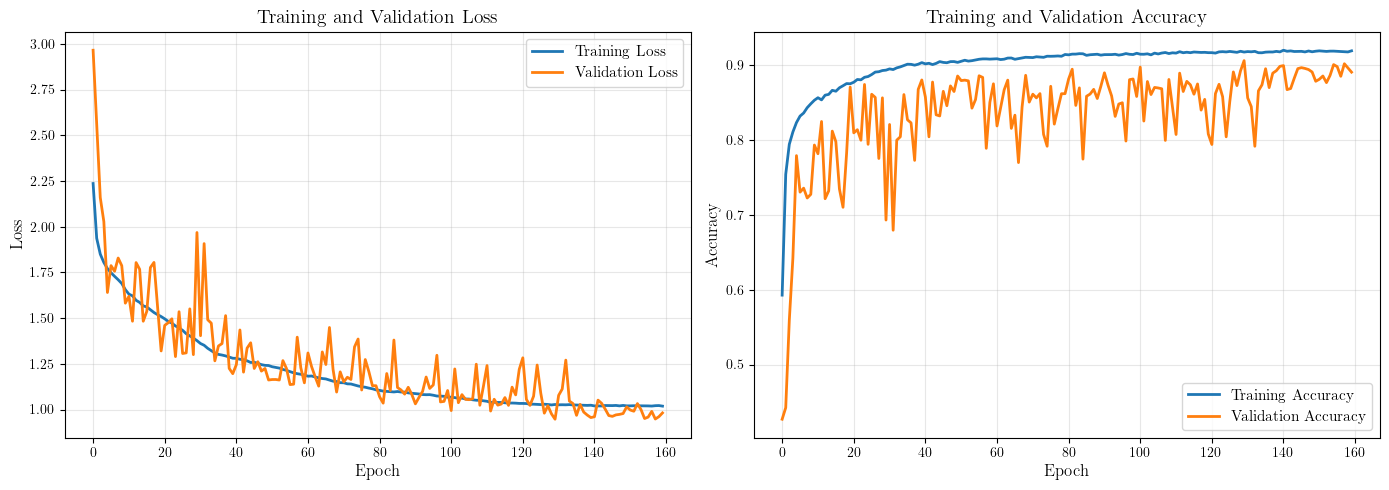

In [7]:
history_qat = train_model(model_qat, X_train,y_train, X_val, y_val, callbacks, batch_size=2048, epochs=300) # Batch according to HGQ article
plot_training_history(history_qat, model_name='posture_classifier_qat', save=True)

## Model Evaluation

In [8]:
class_report_metric(model_qat, X_test, y_test, class_names)

I0000 00:00:1780590463.913737    5042 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.



Accuracy Report for `posture_classifier_qat`:
  Loss: 0.9535
  Accuracy: 90.31%

Classification Report for `posture_classifier_qat`:
              precision    recall  f1-score   support

   lateral_L     0.9267    0.8803    0.9029     40000
   lateral_R     0.8877    0.9119    0.8996     40000
      supine     0.8966    0.9171    0.9068     40001

    accuracy                         0.9031    120001
   macro avg     0.9037    0.9031    0.9031    120001
weighted avg     0.9037    0.9031    0.9031    120001



In [9]:
# Inspect learned quantization bit-widths
# bits_info = inspect_quantization_bits(model_qat, report=True)

# plot_quantization_bits(model_qat, bits_info=bits_info, save=False)


In [10]:
# From larger_jet_tagger

# When using `WRAP` overflow mode for activations (datalane), HGQ2 needs to know the min/max values of each layer's activations to determine the required integer bits. 
trace_minmax(model_qat, X_train, batch_size=2048, reset=True)
ebops = trace_minmax(model_qat, X_val, batch_size=2048, reset=False)

lut_pred = np.exp(0.985 * np.log(ebops))
dsp_pred = (ebops - lut_pred) / 55

print("Resource Estimation Report")
print("="*40)
print(f"\nEBOPs: {ebops} \nLUTs: {lut_pred:.0f} \nDSPs: {dsp_pred:.0f}")

Resource Estimation Report

EBOPs: 1395985 
LUTs: 1129035 
DSPs: 4854


In [11]:
## Determine accuracy of Keras model, for comparison
keras_score = model_qat.evaluate(X_test, y_test, verbose=0)

print("="*80)    
print("Keras  model evaluation \t Loss: {:.2f} \t Accuracy: {:.2f}%".format(keras_score[0], keras_score[1]*100))
print("="*80)

Keras  model evaluation 	 Loss: 1.18 	 Accuracy: 81.75%


In [12]:
# Inspect learned quantization bit-widths
bits_info = inspect_quantization_bits(model_qat, report=True)

# plot_quantization_bits(model_qat, bits_info=bits_info, save=False)


Quantization Bit-width Report:
pressure_map: InputLayer (no quantizers)

qconv_1 (QConv2D):
  iq: bits=5.75, fbits=5.75, type=kif
  kq: bits=5.72, fbits=6.72, type=kbi

bn_conv_1 (QBatchNormalization):
  iq: bits=5.93, fbits=6.93, type=kif
  kq: bits=6.00, fbits=7.00, type=kbi
  bq: bits=3.00, fbits=4.00, type=kbi
conv_act_1: Activation (no quantizers)

qconv_2 (QConv2D):
  iq: bits=4.08, fbits=4.08, type=kif
  kq: bits=4.85, fbits=5.85, type=kbi

bn_conv_2 (QBatchNormalization):
  iq: bits=5.98, fbits=6.98, type=kif
  kq: bits=5.50, fbits=6.50, type=kbi
  bq: bits=3.00, fbits=4.00, type=kbi
conv_act_2: Activation (no quantizers)

qconv_3 (QConv2D):
  iq: bits=4.42, fbits=4.42, type=kif
  kq: bits=4.88, fbits=5.88, type=kbi

bn_conv_3 (QBatchNormalization):
  iq: bits=6.22, fbits=7.22, type=kif
  kq: bits=5.33, fbits=6.33, type=kbi
  bq: bits=3.00, fbits=4.00, type=kbi
conv_act_3: Activation (no quantizers)
flatten: Flatten (no quantizers)

qdense_1 (QDense):
  iq: bits=5.18, fbits=5.

## Model Saving

In [13]:
# Save model
save_model(model_qat, output_dir='output')


Model saved to: output/posture_classifier_qat.keras

Verification:
  Loaded successfully: True
  Model name: posture_classifier_qat
  Total parameters: 59,749
